In [2]:
from model.dadmd import DA_DMD
from utils import standardize_minmax
import torch
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# Train the model

In [124]:
"""
Train the DA-DMD model using synthetic data and save the model.

"""

loss_fn = nn.MSELoss()

def train_model(model, train_loader, num_epochs=50, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()
    for epoch in range(num_epochs):
        train_loss = 0.0
        for X_batch, Y_batch in train_loader:
            optimizer.zero_grad()
            _, reconstructed = model(X_batch)
            loss = loss_fn(reconstructed, Y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {train_loss / len(train_loader):.6f}")
    return model




hankel_dim = 40

cars = standardize_minmax(np.load('synthetic_data/cars_5000.npy'))
raman = standardize_minmax(np.load('synthetic_data/raman_5000.npy'))

diff_cars = standardize_minmax(np.load('synthetic_data/expand_cars_1d_new.npy'))
diff_raman = standardize_minmax(np.load('synthetic_data/expand_raman_1d_new.npy'))

train_cars = np.concatenate((cars[:5000, :656], diff_cars[:3000, :656]), axis=0)
train_raman = np.concatenate((raman[:5000, :656], diff_raman[:3000, :656]), axis=0)

X_noisy = torch.tensor(train_cars, dtype=torch.float32).to(device)
X_clean = torch.tensor(train_raman, dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_noisy, X_clean)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

model = DA_DMD(input_dim=656, num_modes=hankel_dim, Ndelay=hankel_dim).to(device)
trained_model = train_model(model, train_loader, num_epochs=50)



Epoch 1/50, Loss: 0.007855
Epoch 2/50, Loss: 0.004517
Epoch 3/50, Loss: 0.004195
Epoch 4/50, Loss: 0.003756
Epoch 5/50, Loss: 0.003598
Epoch 6/50, Loss: 0.003449
Epoch 7/50, Loss: 0.003256
Epoch 8/50, Loss: 0.003183
Epoch 9/50, Loss: 0.003150
Epoch 10/50, Loss: 0.003425
Epoch 11/50, Loss: 0.003067
Epoch 12/50, Loss: 0.002914
Epoch 13/50, Loss: 0.002894
Epoch 14/50, Loss: 0.002884
Epoch 15/50, Loss: 0.002788
Epoch 16/50, Loss: 0.002789
Epoch 17/50, Loss: 0.002752
Epoch 18/50, Loss: 0.002724
Epoch 19/50, Loss: 0.002693
Epoch 20/50, Loss: 0.002709
Epoch 21/50, Loss: 0.002628
Epoch 22/50, Loss: 0.002592
Epoch 23/50, Loss: 0.002686
Epoch 24/50, Loss: 0.002573
Epoch 25/50, Loss: 0.002578
Epoch 26/50, Loss: 0.002533
Epoch 27/50, Loss: 0.002546
Epoch 28/50, Loss: 0.002511
Epoch 29/50, Loss: 0.002454
Epoch 30/50, Loss: 0.002436
Epoch 31/50, Loss: 0.002445
Epoch 32/50, Loss: 0.002445
Epoch 33/50, Loss: 0.002418
Epoch 34/50, Loss: 0.002408
Epoch 35/50, Loss: 0.002392
Epoch 36/50, Loss: 0.002373
E

# Save model

In [125]:
## save the model
torch.save(trained_model, 'pretrained_models/5000S+3000D_656.pt')

# Test the model

In [ ]:
from sklearn.metrics import mean_squared_error
from utils import normalize


def denoise_spectrum(model, raw_spectrum):
    """
    Pass a raw Raman spectrum through the DA-DMD model to denoise it.

    Args:
        model (torch.nn.Module): Trained DA-DMD model
        raw_spectrum (np.ndarray): 1D input spectrum of shape (spectrum_length,)

    Returns:
        np.ndarray: Denoised output spectrum of shape (spectrum_length,)
    """
    model.eval()
    spectrum_tensor = torch.tensor(raw_spectrum, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        _, denoised_spectrum = model(spectrum_tensor)

    return denoised_spectrum.cpu().numpy().squeeze()



# Load and preprocess data
cars = standardize_minmax(np.load('synthetic_data/2_cars_2000.npy'))
raman = standardize_minmax(np.load('synthetic_data/2_raman_2000.npy'))

X_noisy = cars[1700:, :]   # test input
X_clean = raman[1700:, :]  # ground truth

# Load model and pretrained weights
trained_model = torch.load('pretrained_models/5000S+3000D_656.pt', weights_only=False)

# Run denoising on all test samples
test_losses = []
for i in range(len(X_noisy)):
    noisy_input = normalize(X_noisy[i]).copy()
    clean_target = normalize(X_clean[i]).copy()

    output = denoise_spectrum(trained_model, noisy_input)

    loss = mean_squared_error(output, clean_target)
    test_losses.append(loss)

    # print(f"Sample {i+1}/{len(X_noisy)} - MSE Loss: {loss:.6f}")

print(f"Average Test Loss: {np.mean(test_losses):.6f}")

/home/lin/miniconda3/envs/env_dadmd/lib/python3.10/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number inf. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/lin/miniconda3/envs/env_dadmd/lib/python3.10/site-packages/pydmd/dmdoperator.py:176: RuntimeWarning: divide by zero encountered in reciprocal
  return np.linalg.multi_dot([U.T.conj(), Y, V]) * np.reciprocal(s)
/home/lin/miniconda3/envs/env_dadmd/lib/python3.10/site-packages/pydmd/dmdoperator.py:176: RuntimeWarning: invalid value encountered in multiply
  return np.linalg.multi_dot([U.T.conj(), Y, V]) * np.reciprocal(s)
/home/lin/miniconda3/envs/env_dadmd/lib/python3.10/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number inf. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/lin/miniconda3/envs/env_dadmd/lib/python3.10/site-packages/pydmd/dmdoperator.py:176

Average Test Loss: 0.001032


/home/lin/miniconda3/envs/env_dadmd/lib/python3.10/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number inf. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/lin/miniconda3/envs/env_dadmd/lib/python3.10/site-packages/pydmd/dmdoperator.py:176: RuntimeWarning: divide by zero encountered in reciprocal
  return np.linalg.multi_dot([U.T.conj(), Y, V]) * np.reciprocal(s)
/home/lin/miniconda3/envs/env_dadmd/lib/python3.10/site-packages/pydmd/dmdoperator.py:176: RuntimeWarning: invalid value encountered in multiply
  return np.linalg.multi_dot([U.T.conj(), Y, V]) * np.reciprocal(s)


# Test the model on real data

In [7]:
import numpy as np
import torch
import os
from sklearn.metrics import mean_squared_error
from utils import normalize

# Make sure device and standardize_minmax are defined in your environment
# from your_script import device, standardize_minmax

def denoise_spectrum(model, raw_spectrum):
    """
    Use trained DA-DMD model to denoise a single input spectrum
    """
    model.eval()
    spectrum_tensor = torch.tensor(raw_spectrum, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        _, denoised_spectrum = model(spectrum_tensor)
    return denoised_spectrum.cpu().numpy().squeeze()

# Load the fully saved trained model checkpoint
trained_model = torch.load('pretrained_models/1700S+1700D_656.pt', weights_only=False)

# Initialize lists to store input CARS spectra and ground-truth Raman spectra
real_noisy_list = []
real_gt_list = []
valid_names = []

# ---------------------- Load all data from 8samples folder ----------------------
root_8 = "real_data/8samples/"
sample_8_names = [
    "4APL",
    "ACN",
    "CYH",
    "DMSO",
    "ETH",
    "MTH",
    "nDO",
    "TOL"
]

for prefix in sample_8_names:
    cars_npy = np.load(os.path.join(root_8, f"{prefix}_CARS.npy"))
    raman_npy = np.load(os.path.join(root_8, f"{prefix}_Raman.npy"))

    # Extract spectrum signal from the 2nd row (index=1), 1st row is wavenumber axis
    cars_spec = cars_npy[1, :]
    # Crop spectrum to fixed 656 points to match model input dimension
    cars_clip = cars_spec[:656]

    # Handle Raman spectrum which may also be a 2-row array
    if len(raman_npy.shape) == 2:
        raman_spec = raman_npy[1, :]
        raman_clip = raman_spec[:656]
    else:
        raman_clip = raman_npy[:656]

    # Only keep samples with exact 656-length spectra
    if len(cars_clip) == 656 and len(raman_clip) == 656:
        real_noisy_list.append(cars_clip)
        real_gt_list.append(raman_clip)
        valid_names.append(f"8samples_{prefix}")
    else:
        print(f"[Skip Invalid Sample - 8samples] {prefix} | CARS length:{len(cars_clip)}, Raman length:{len(raman_clip)}")

# ---------------------- Load all data from 6samples folder ----------------------
root_6 = "real_data/6samples/"
solvent_name_mapping = {
    1: "Acetone",
    2: "DMSO",
    3: "Ethanol",
    4: "Methanol",
    5: "Toluene",
    6: "Isopropanol"
}

for sample_id in range(1, 7):
    car_file_path = os.path.join(root_6, f"CARS_solvent_{sample_id}.npy")
    raman_file_path = os.path.join(root_6, f"Raman_solvent_{sample_id}_{solvent_name_mapping[sample_id]}.npy")
    cars_npy = np.load(car_file_path)
    raman_npy = np.load(raman_file_path)

    # Extract spectrum row for CARS data
    if len(cars_npy.shape) == 2:
        cars_spec = cars_npy[1, :]
    else:
        cars_spec = cars_npy
    cars_clip = cars_spec[:656]

    # Extract spectrum row for Raman ground truth
    if len(raman_npy.shape) == 2:
        raman_spec = raman_npy[1, :]
        raman_clip = raman_spec[:656]
    else:
        raman_clip = raman_npy[:656]

    if len(cars_clip) == 656 and len(raman_clip) == 656:
        real_noisy_list.append(cars_clip)
        real_gt_list.append(raman_clip)
        valid_names.append(f"6samples_{solvent_name_mapping[sample_id]}")
    else:
        print(f"[Skip Invalid Sample - 6samples] solvent_{sample_id} | CARS length:{len(cars_clip)}, Raman length:{len(raman_clip)}")

# Convert list data into standard numpy array format
X_noisy_real = np.array(real_noisy_list) if real_noisy_list else np.array([])
X_clean_real = np.array(real_gt_list) if real_gt_list else np.array([])

# Calculate MSE loss for all valid real experimental data
real_mse_results = []
if len(X_noisy_real) > 0:
    for idx in range(len(X_noisy_real)):
        input_spec = normalize(X_noisy_real[idx]).copy()
        target_spec = normalize(X_clean_real[idx]).copy()
        pred_spec = denoise_spectrum(trained_model, input_spec)
        single_mse = mean_squared_error(pred_spec, target_spec)
        real_mse_results.append(single_mse)
        print(f"Test Sample {valid_names[idx]} | Single MSE Loss: {single_mse:.6f}")

# Final statistical output
print("-" * 70)
if real_mse_results:
    print(f"Total valid real-world test samples: {len(valid_names)}")
    print(f"Average MSE Loss over all real experimental data: {np.mean(real_mse_results):.6f}")
else:
    print("No valid real data available for testing, please check npy file format and spectrum length")

Test Sample 8samples_4APL | Single MSE Loss: 0.049442
Test Sample 8samples_ACN | Single MSE Loss: 0.019908
Test Sample 8samples_CYH | Single MSE Loss: 0.057801
Test Sample 8samples_DMSO | Single MSE Loss: 0.024835
Test Sample 8samples_ETH | Single MSE Loss: 0.081752
Test Sample 8samples_MTH | Single MSE Loss: 0.136375
Test Sample 8samples_nDO | Single MSE Loss: 0.127757
Test Sample 8samples_TOL | Single MSE Loss: 0.025071
Test Sample 6samples_Acetone | Single MSE Loss: 0.007076
Test Sample 6samples_DMSO | Single MSE Loss: 0.005724
Test Sample 6samples_Ethanol | Single MSE Loss: 0.004346
Test Sample 6samples_Methanol | Single MSE Loss: 0.009880
Test Sample 6samples_Toluene | Single MSE Loss: 0.007559
Test Sample 6samples_Isopropanol | Single MSE Loss: 0.008761
----------------------------------------------------------------------
Total valid real-world test samples: 14
Average MSE Loss over all real experimental data: 0.040449


# Plot a DA-DMD reconstruction

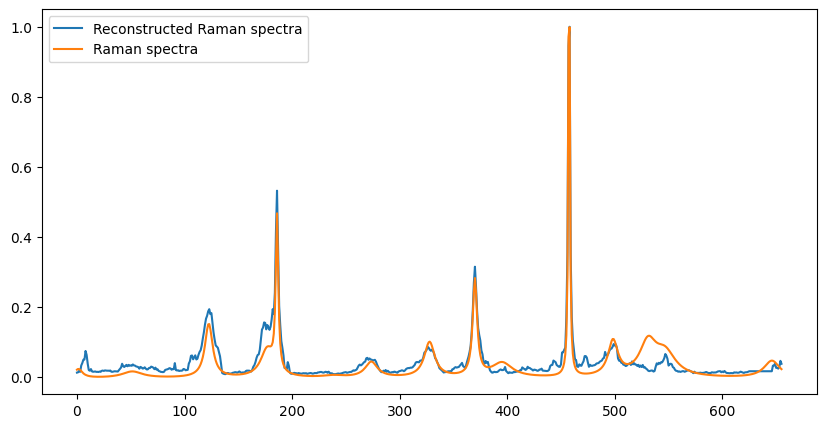

In [104]:
import matplotlib.pyplot as plt

noisy = cars[1997, :] 
clean = raman[1997, :] 
result = denoise_spectrum(trained_model, noisy)

plt.figure(figsize=(10,5))
plt.plot(result, label='Reconstructed Raman spectra')
plt.plot(clean, label='Raman spectra')
plt.legend()
plt.savefig("output.png", dpi=300, bbox_inches="tight")
plt.show()